Understanding PCA from the scratch Mathemetically

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
np.random.seed(101)
mu_vec1 = [0,0,0]
cov_mat1 = [[1,0,0],[0,1,0],[0,0,1]]
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 0 # Changed target to 0 for class1 for distinction

mu_vec2 = [1,1,1]
cov_mat2 = [[1,0,0],[0,1,0],[0,0,1]]
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3']) # Corrected: assigned to df1
df1['target'] = 1

df = pd.concat([df, df1], ignore_index=True) # Changed from append to concat
df = df.sample(40)

In [5]:
df.head()

,feature1,feature2,feature3,target
0,2.706850,0.628133,0.907969,0
10,0.638787,0.329646,-0.497104,0
6,2.605967,0.683509,0.302665,0
13,1.996652,-0.993263,0.196800,0
14,-1.136645,0.000366,1.025984,0


In [6]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

scalar.fit


<bound method StandardScaler.fit of StandardScaler()>

In [8]:
cov_matrix = np.cov([df.iloc[:,0], df.iloc[:,1], df.iloc[:,2]])

In [9]:
igen_value,igen_vector = np.linalg.eig(cov_matrix)

In [10]:
igen_value

array([1.5976957 , 1.01542739, 0.92389243])

In [11]:
igen_vector

array([[ 0.25790413, -0.9660933 ,  0.01221437],
       [-0.81641819, -0.22467313, -0.53196177],
       [-0.51666894, -0.12722311,  0.84668028]])

In [28]:
# Top 2 eigenvectors
top2 = igen_vector[:2]
top2


array([[ 0.25790413, -0.9660933 ,  0.01221437],
       [-0.81641819, -0.22467313, -0.53196177]])

In [32]:
transformed_df = np.dot(df.iloc[:,:3], top2.T)

In [33]:
new_df = pd.DataFrame(transformed_df, columns=['PC1', 'PC2'])
new_df['target'] = df['target']
new_df.head()

,PC1,PC2,target
0,0.102363,-2.834051,0
1,-0.159795,-0.331140,0
2,0.015453,-2.442132,0
3,1.476934,-1.511633,0
4,-0.280968,0.382111,0


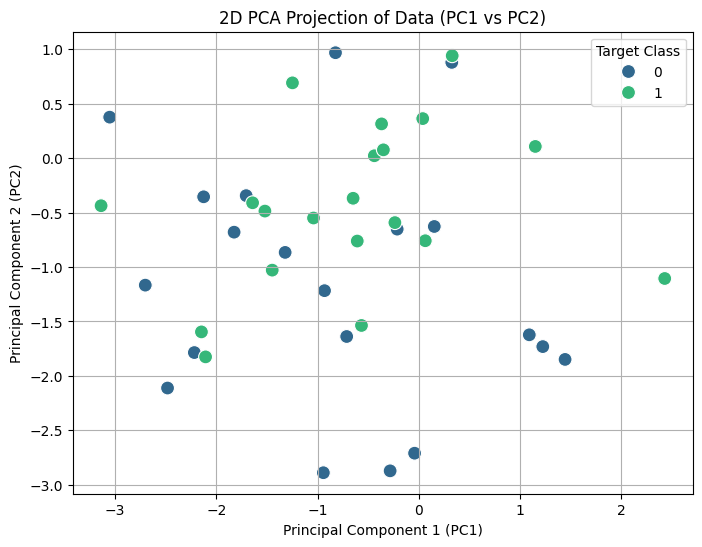

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='target', data=new_df, palette='viridis', s=100)
plt.title('2D PCA Projection of Data (PC1 vs PC2)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True)
plt.legend(title='Target Class')
plt.show()